# Import required packages
#### Python 3.7.9

In [1]:
from collections import Counter
import math
import os
import pickle
import pprint

from  matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import nrrd
import numpy as np
import scipy.spatial
import SimpleITK as sitk
from tqdm import tqdm

# Get the project path

In [2]:
PROJECT_PATH = 'data'

SUBJECT_ID = 'subject-1___healthy-volunteer' #'subject-2___patient'
GROUND_TRUTH_PATH = os.path.join(PROJECT_PATH, SUBJECT_ID, 'ground_truth')
MODEL_PATH = os.path.join(PROJECT_PATH, SUBJECT_ID, 'model')
STRUCTURE_PATH = 'structures'
ALL_SEG_NAMES = set([f.split('_v')[0] for f in os.listdir(GROUND_TRUTH_PATH) if f.endswith('.nii')])
CHECKPOINT_PATH = 'checkpoints'
LOAD_CHECKPOINT = False

# From: 10.1002/mp.16582
TR_REF = 1535
TE_REF = 212

# Read in all the weighted images

In [3]:
# subject : {(TR, TE): []}
all_weighted_images = {SUBJECT_ID: {}}

# Load all of the contrast weightings
all_weightings = os.listdir(MODEL_PATH)
for weighting in tqdm(all_weightings):
    # Load all of the images for the desired contrast weighting
    pixel_array, header = nrrd.read(os.path.join(MODEL_PATH, weighting, 'img.nrrd'))
    pixel_array = np.transpose(pixel_array, (2,1,0))
    # Save to dictionary
    temp_TR = int(weighting.split('_')[0].split('TR')[1])
    temp_TE = int(weighting.split('_')[1].split('TE')[1])
    all_weighted_images[SUBJECT_ID][(temp_TR, temp_TE)] = pixel_array


100%|██████████| 216/216 [00:57<00:00,  3.78it/s]


# Visualize all of the weighted images

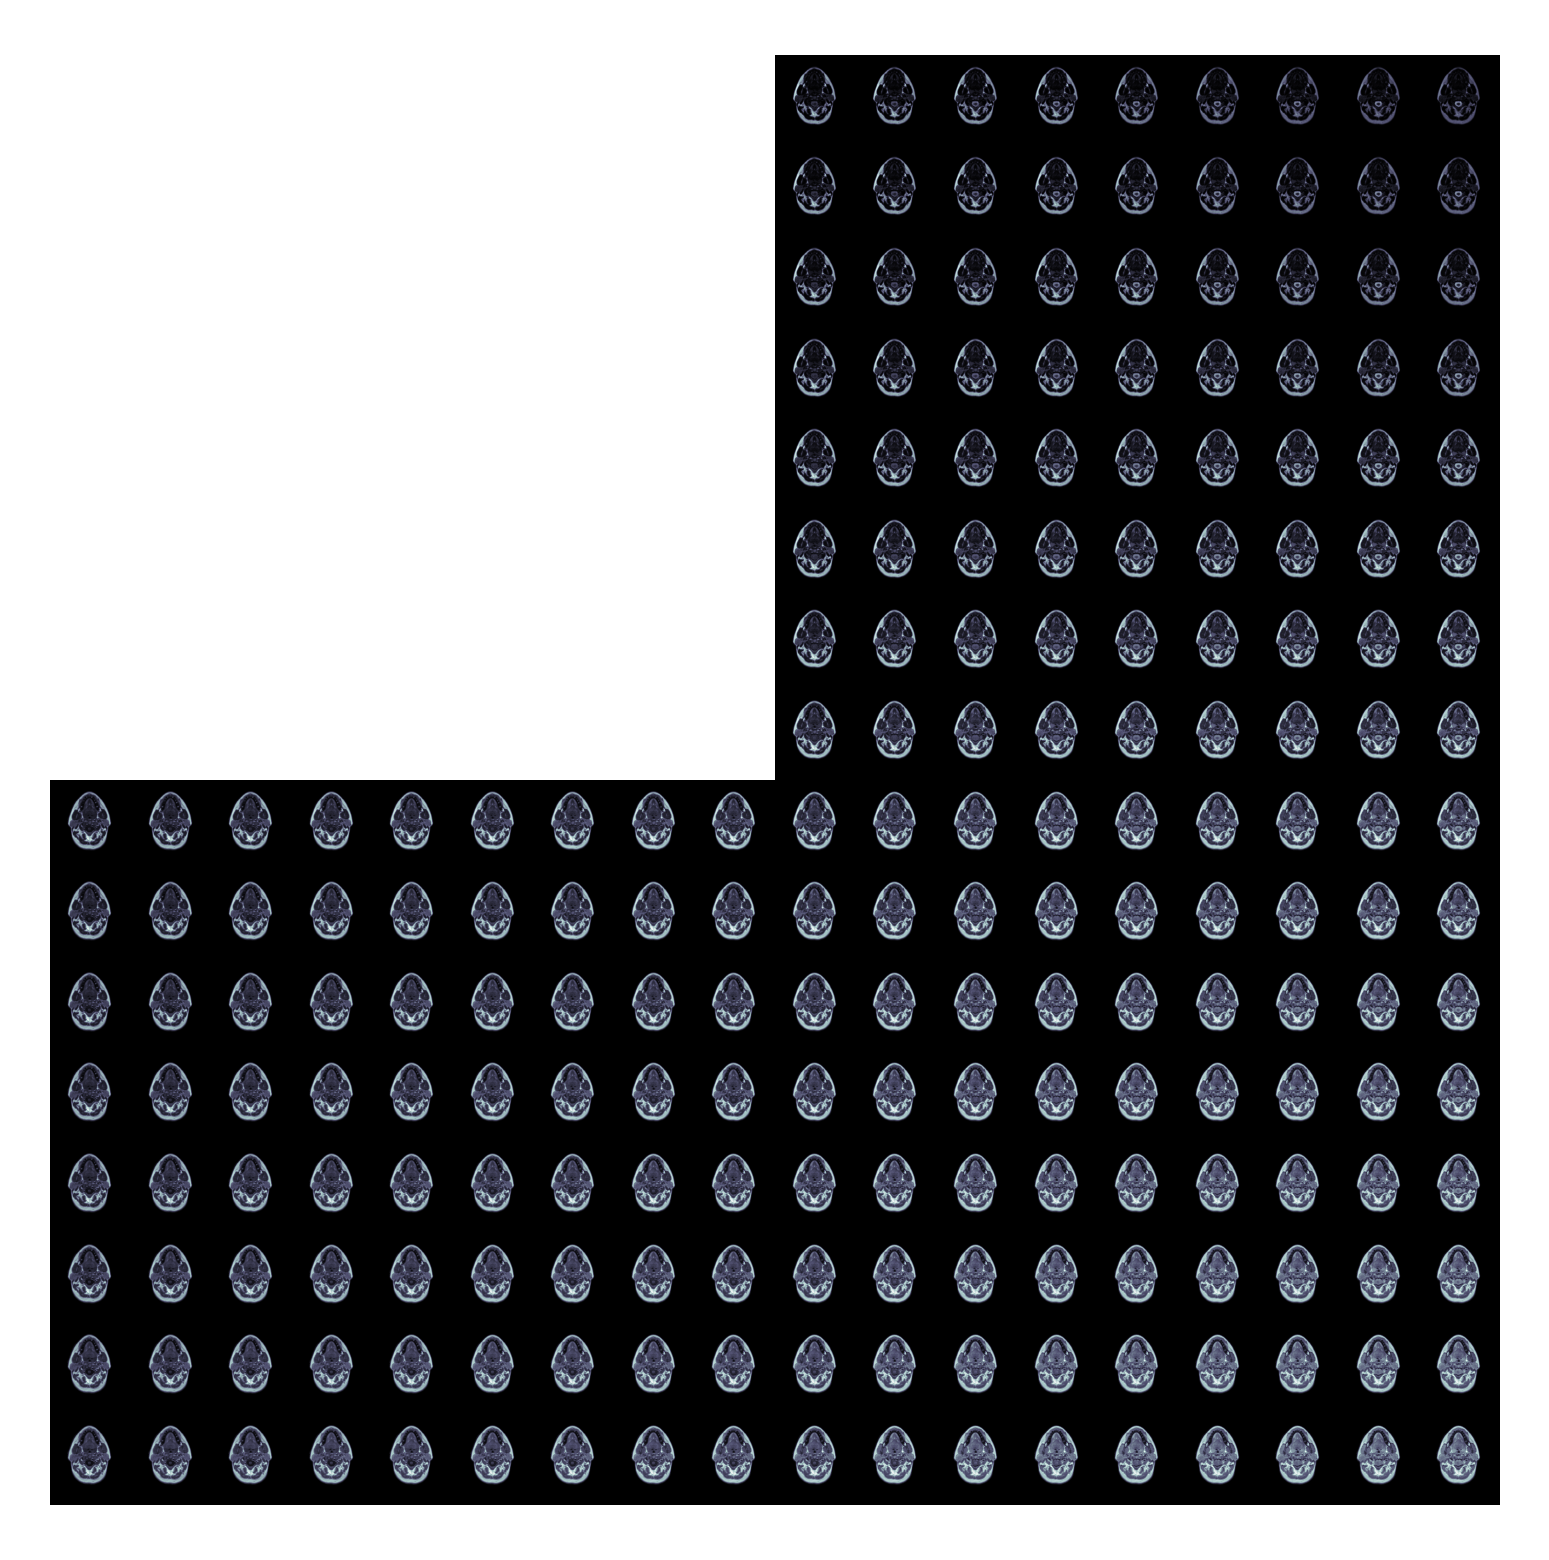

In [4]:
EQUAL_SPACING = True

# Visualize all TR and TE
all_TR = sorted(list(set([w[0] for w in all_weighted_images[SUBJECT_ID].keys()])))
all_TE = sorted(list(set([w[1] for w in all_weighted_images[SUBJECT_ID].keys()])))
# Or select the TR and TE
# all_TR = [100,500,1000,1500,2000,2500,3000,3500,4000,4500,5000]
# all_TE = [5,20,40,60,80,100,120,140,160,180,200]

if not EQUAL_SPACING:
    max_TR = max(all_TR)
    max_TE = max(all_TE)

fig,ax = plt.subplots(figsize=(20,20))
for temp_weighting in all_weighted_images[SUBJECT_ID].keys():
    temp_TR = temp_weighting[0]
    temp_TE = temp_weighting[1]
    try:
        temp_TR_ind = all_TR.index(temp_TR)
        temp_TE_ind = all_TE.index(temp_TE)
    except ValueError:
        continue
    if EQUAL_SPACING:
        min_x = (temp_TR_ind - 0.5)/len(all_TR)
        max_x = (temp_TR_ind + 0.5)/len(all_TR)
        min_y = (temp_TE_ind - 0.5)/len(all_TE)
        max_y = (temp_TE_ind + 0.5)/len(all_TE)
        extent = [min_x, max_x, min_y, max_y]
    else:
        # Get TR bounds
        if temp_TR_ind == 0:
            min_x = -(all_TR[temp_TR_ind] + all_TR[temp_TR_ind+1]) / 2
        else:
            min_x = (all_TR[temp_TR_ind-1] + all_TR[temp_TR_ind]) / 2
        if temp_TR_ind == len(all_TR)-1:
            max_x = max_TR + (all_TR[temp_TR_ind-1] + all_TR[temp_TR_ind]) / 2
        else:
            max_x = (all_TR[temp_TR_ind] + all_TR[temp_TR_ind+1]) / 2
        # Get TE bounds
        if temp_TE_ind == 0:
            min_y = -(all_TE[temp_TE_ind] + all_TE[temp_TE_ind+1]) / 2
        else:
            min_y = (all_TE[temp_TE_ind-1] + all_TE[temp_TE_ind]) / 2
        if temp_TE_ind == len(all_TE)-1:
            max_y = max_TE + (all_TE[temp_TE_ind-1] + all_TE[temp_TE_ind]) / 2
        else:
            max_y = (all_TE[temp_TE_ind] + all_TE[temp_TE_ind+1]) / 2
        extent = [min_x/max_TR, max_x/max_TR, min_y/max_TE, max_y/max_TE]
    # Plot the results
    temp_image = all_weighted_images[SUBJECT_ID][temp_weighting]
    ax.imshow(temp_image[int(temp_image.shape[0]/2),:,:], extent=extent, cmap=plt.cm.bone)

if EQUAL_SPACING:
    plt.xlim([-1/len(all_TR),1])
    plt.ylim([-1/len(all_TE),1])
else:
    plt.xlim([-0.1,1.1])
    plt.ylim([-0.1,1.1])
plt.axis('off')
plt.show()


# Create a STAPLE of the ground truth segmentations

In [5]:
STAPLE_segs = {}

for seg_name in ALL_SEG_NAMES:
    print(seg_name)
    n_reviewers = len([s for s in os.listdir(GROUND_TRUTH_PATH) if seg_name in s])
    struct_mask = [
        # (z,x,y) -> (x,y,z)
        sitk.GetArrayFromImage(sitk.ReadImage(os.path.join(GROUND_TRUTH_PATH, f'{seg_name}_v{n+1}.nii'))).transpose(1,2,0) for n in range(n_reviewers)
    ]
    # Only do the non-zero slices to increase speed
    final_STAPLE_seg = np.zeros(struct_mask[0].shape)
    all_slice_vals = np.sum(sum(struct_mask), axis=(0,1))
    for s,slice_sum in enumerate(tqdm(all_slice_vals)):
        if slice_sum > 0:
            STAPLE_seg_stack = []
            # Assume all segmentations are the same dimensions
            plot_im = np.zeros(struct_mask[0][:,:,s].shape)
            for nr in range(n_reviewers):
                where_mask = np.where(struct_mask[nr][:,:,s] == 1)
                plot_im[where_mask] = nr+1
                STAPLE_seg_stack.append(
                    sitk.GetImageFromArray(struct_mask[nr][:,:,s].astype(np.int16))
                )
            STAPLE_seg = sitk.STAPLE(STAPLE_seg_stack, 1)
            STAPLE_seg = sitk.GetArrayFromImage(STAPLE_seg)
            try:
                # plt.figure(figsize=(4,4))
                # plt.imshow(plot_im, cmap=plt.cm.hot)
                # plt.axis('off')
                # plt.title('Separate')
                # plt.show()
                # plt.figure()
                # plt.hist(STAPLE_seg)
                # plt.show()
                # TODO: is 0.1 a good threshold?
                STAPLE_seg = np.where(STAPLE_seg>0.1, 1, 0)
                # plt.figure(figsize=(4,4))
                # plt.imshow(STAPLE_seg, cmap=plt.cm.hot)
                # plt.axis('off')
                # plt.title('STAPLE')
                # plt.show()
                final_STAPLE_seg[:,:,s] = STAPLE_seg
            except ValueError:
                pass

        STAPLE_segs[seg_name] = final_STAPLE_seg


Glnd_Submand_L


100%|██████████| 30/30 [00:00<00:00, 31.92it/s]


Parotid_R


100%|██████████| 30/30 [00:00<00:00, 31.40it/s]


Glnd_Submand_R


100%|██████████| 30/30 [00:00<00:00, 46.19it/s]


Parotid_L


100%|██████████| 30/30 [00:00<00:00, 35.86it/s] 


# Read in the DL segmentations

In [6]:
if not LOAD_CHECKPOINT:
    all_DL_segs = {}

    for temp_weighting in tqdm(all_weighted_images[SUBJECT_ID].keys()):
        all_DL_segs[temp_weighting] = {}
        folder_name = f'TR{temp_weighting[0]}_TE{temp_weighting[1]}'

        for seg_name in ALL_SEG_NAMES:
            struct_mask,header = nrrd.read(os.path.join(MODEL_PATH, folder_name, STRUCTURE_PATH, f'{seg_name}.nrrd'))
            struct_mask = np.transpose(struct_mask, (1,0,2))
            img_1 = STAPLE_segs[seg_name].astype(np.int8)
            img_2 = struct_mask.astype(np.int8)
            # Dice Score
            dice_score = sitk.LabelOverlapMeasuresImageFilter()
            dice_score.Execute(
                sitk.GetImageFromArray(img_1),
                sitk.GetImageFromArray(img_2)
            )
            dice_score = dice_score.GetDiceCoefficient()
            # Hausdorff distance
            # NOTE: normal Hausdorff distance
            hausdorff_distance = sitk.HausdorffDistanceImageFilter()
            hausdorff_distance.Execute(
                sitk.GetImageFromArray(img_1),
                sitk.GetImageFromArray(img_2)
            )
            hausdorff_distance = hausdorff_distance.GetHausdorffDistance()
            # NOTE: 95th percentile Hausdorff distance
            def getDistancesFromAtoB(a, b):
                kdTree = scipy.spatial.KDTree(a, leafsize=100)
                return kdTree.query(b, k=1, eps=0, p=2)[0]

            dist_test_to_result = getDistancesFromAtoB(np.stack(np.where(img_1==1), axis=1), np.stack(np.where(img_2==1), axis=1))
            dist_result_to_test = getDistancesFromAtoB(np.stack(np.where(img_2==1), axis=1), np.stack(np.where(img_1==1), axis=1))
            hausdorff_distance_95 = max(np.percentile(dist_test_to_result, 95), np.percentile(dist_result_to_test, 95))
            # Save the metrics
            percentiles = np.arange(1,100,1)
            hausdorff_distance_all = [max(np.percentile(dist_test_to_result, p), np.percentile(dist_result_to_test, p)) for p in percentiles]
            all_DL_segs[temp_weighting][seg_name] = {
                'Dice Score': dice_score,
                'Hausdorff Distance': hausdorff_distance,
                'Hausdorff Distance (95th Percentile)': hausdorff_distance_95,
                'Hausdorff Distance (All)': hausdorff_distance_all
            }

    # Save the dictionary since it takes a while to compute
    with open(os.path.join('checkpoints', f'all_DL_segs___{SUBJECT_ID}.pkl'), 'wb') as f:
        pickle.dump(all_DL_segs, f)

100%|██████████| 216/216 [25:06<00:00,  6.98s/it]


# Visualize the different HD percentiles

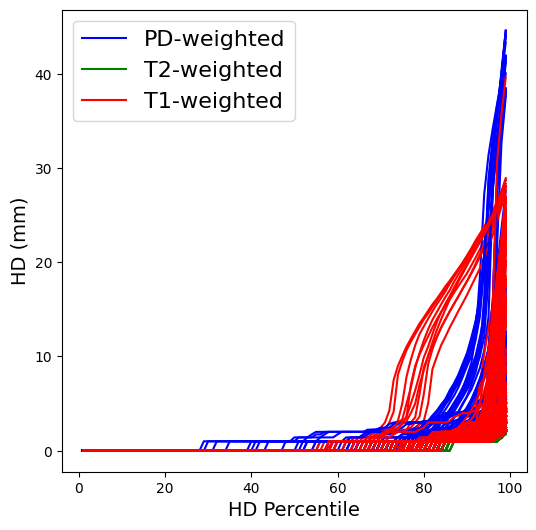

In [7]:
colors = ['r','g','b']
all_percentages = []
plt.figure(figsize=(6,6))
percentiles = np.arange(1,100,1)
t1w_count = 0
t2w_count = 0
pd_count = 0
for tw in all_DL_segs.keys():
    if (tw[0] <= 900) and (tw[1] <= 40):
        color = colors[0]
        label = 'T1-weighted'
        t1w_count += 1
    elif (tw[0] >= 1000) and (tw[1] >= 60):
        color = colors[1]
        label = 'T2-weighted'
        t2w_count += 1
    elif (tw[0] >= 1000) and (tw[1] <= 40):
        color = colors[2]
        label = 'PD-weighted'
        pd_count += 1
    for d,dsn in enumerate(all_DL_segs[tw].keys()):
        if type(all_DL_segs[tw][dsn]) is dict:
            all_percentages.append(all_DL_segs[tw][dsn]['Hausdorff Distance (All)'])
            if t1w_count == 1:
                plt.plot(percentiles, all_DL_segs[tw][dsn]['Hausdorff Distance (All)'], color=color, label=label)
                t1w_count += 1
            elif t2w_count == 1:
                plt.plot(percentiles, all_DL_segs[tw][dsn]['Hausdorff Distance (All)'], color=color, label=label)
                t2w_count += 1
            elif pd_count == 1:
                plt.plot(percentiles, all_DL_segs[tw][dsn]['Hausdorff Distance (All)'], color=color, label=label)
                pd_count += 1
            else:
                plt.plot(percentiles, all_DL_segs[tw][dsn]['Hausdorff Distance (All)'], color=color)
plt.xlabel('HD Percentile', fontsize=14)
plt.ylabel('HD (mm)', fontsize=14)
plt.legend(fontsize=16)
plt.show()


# Or ... load checkpoint instead

In [8]:
if LOAD_CHECKPOINT:
    with open(os.path.join(CHECKPOINT_PATH, f'all_DL_segs___{SUBJECT_ID}.pkl'), 'rb') as f:
        all_DL_segs = pickle.load(f)

    # Preview the loaded dictionary
    pprint.pprint(dict(list(all_DL_segs.items())[:1]))

    # Extract all TR and TE
    all_TR = sorted(set([d[0] for d in all_DL_segs.keys()]))
    all_TE = sorted(set([d[1] for d in all_DL_segs.keys()]))

    print(all_TR)
    print(all_TE)

# Plot the results

Dice Score


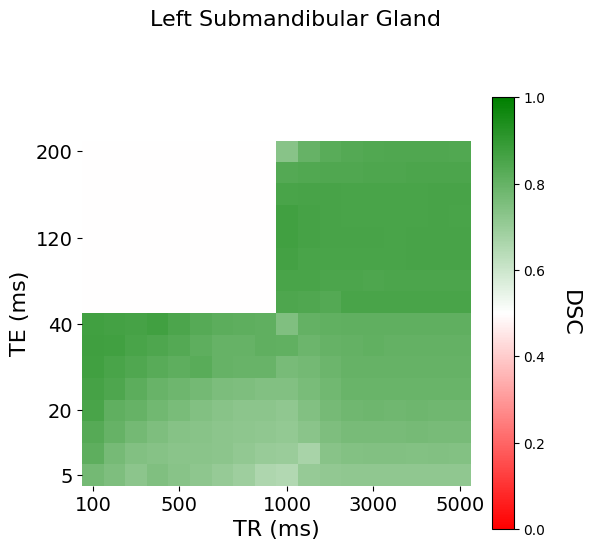

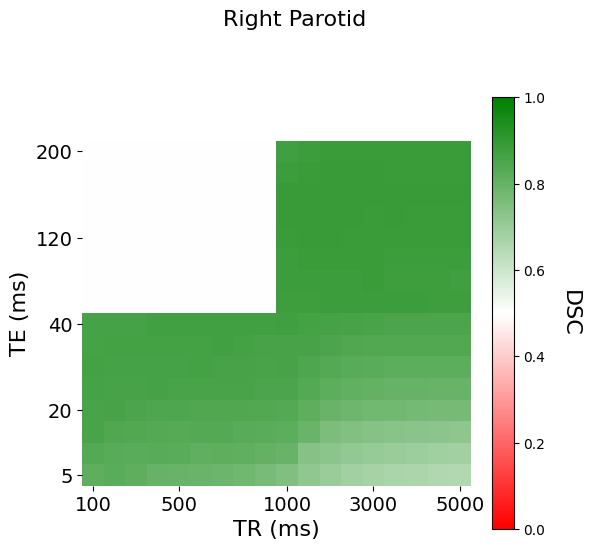

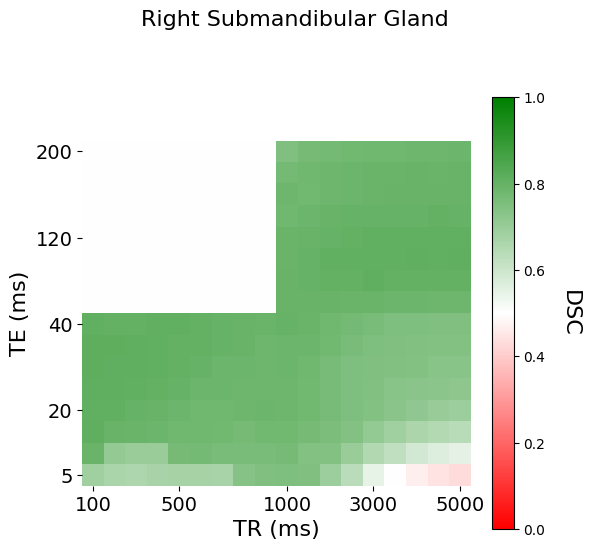

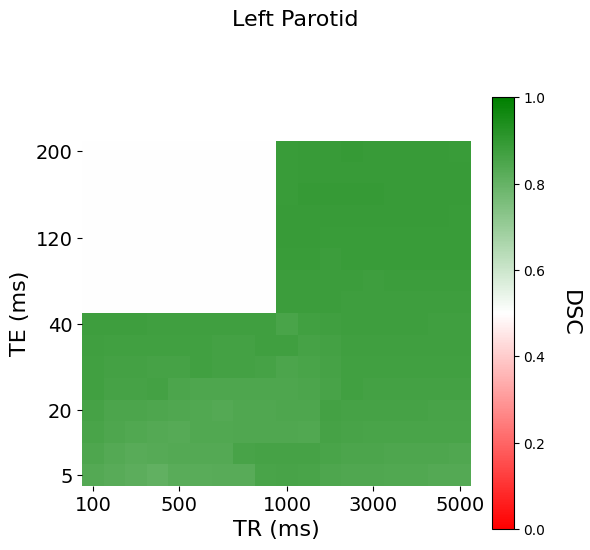

Hausdorff Distance (95th Percentile)


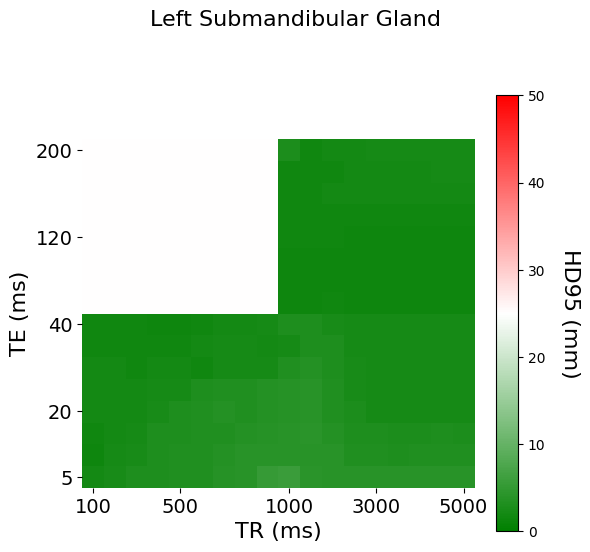

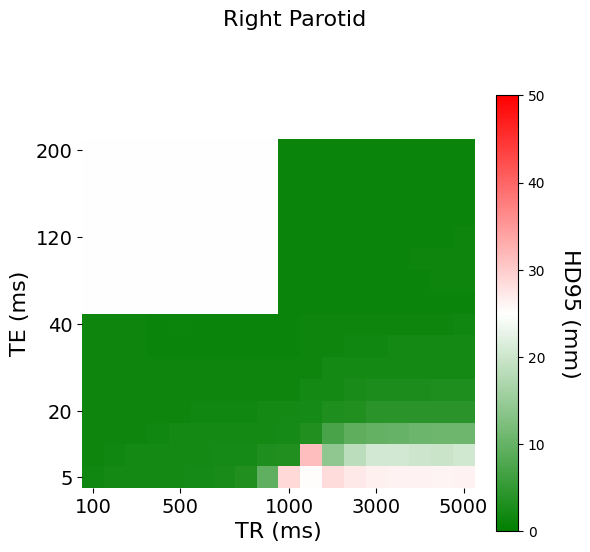

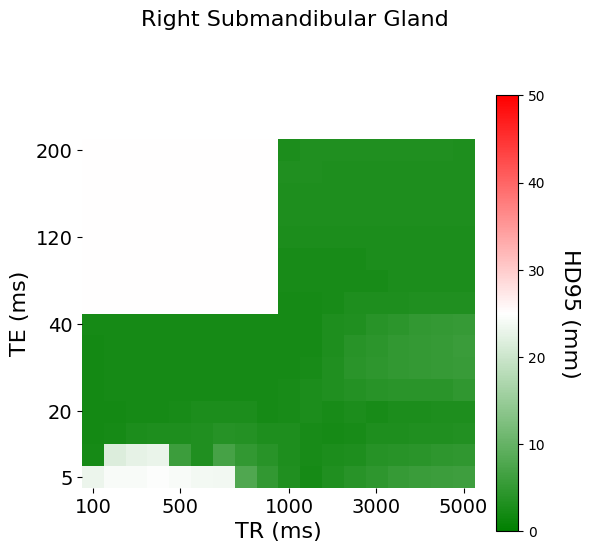

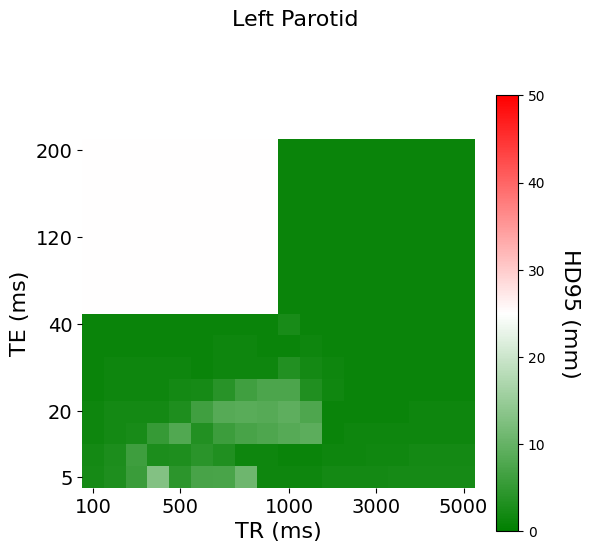

In [9]:
r2g_cmap = LinearSegmentedColormap.from_list('rg', ['r','w','g'], N=256)
g2r_cmap = LinearSegmentedColormap.from_list('gr', ['g','w','r'], N=256)
all_metrics = ['Dice Score', 'Hausdorff Distance (95th Percentile)']

for metric in all_metrics:
    print(metric)

    for seg_name in ALL_SEG_NAMES:
        fig,ax = plt.subplots(1, 1, figsize=(6,6))
        plot_matrix = np.zeros((len(all_TE), len(all_TR)))
        plot_matrix[:] = np.nan

        for temp_weighting in all_DL_segs.keys():
            temp_TR = temp_weighting[0]
            temp_TE = temp_weighting[1]
            temp_TR_ind = all_TR.index(temp_TR)
            temp_TE_ind = all_TE.index(temp_TE)
            try:
                plot_matrix[temp_TE_ind, temp_TR_ind] = all_DL_segs[temp_weighting][seg_name][metric]
            except TypeError:
                plot_matrix[temp_TE_ind, temp_TR_ind] = np.nan

        if metric == 'Dice Score':
            saved_metric = 'DSC'
            # Fill in the mixed contrast region with white
            plot_matrix[-all_TE.index(60):,:all_TR.index(1000)] = 0.5
            plot_im = ax.imshow(plot_matrix, cmap=r2g_cmap, vmin=0, vmax=1, origin='lower')
        elif metric == 'Hausdorff Distance (95th Percentile)':
            saved_metric = 'HD95 (mm)'
            # Fill in the mixed contrast region with white
            plot_matrix[-all_TE.index(60):,:all_TR.index(1000)] = 25 #40
            plot_im = ax.imshow(plot_matrix, cmap=g2r_cmap, vmin=0, vmax=50, origin='lower') # 0, 100

        TR_keep_inds = [100, 500, 1000, 3000, 5000]
        TE_keep_inds = [5, 20, 40, 120, 200]
        ax.set_xticks([all_TR.index(ind) for ind in TR_keep_inds])
        ax.set_yticks([all_TE.index(ind) for ind in TE_keep_inds])
        ax.set_xticklabels(TR_keep_inds, fontsize=14)
        ax.set_yticklabels(TE_keep_inds, fontsize=14)
        ax.set_xlabel('TR (ms)', fontsize=16)
        ax.set_ylabel('TE (ms)', fontsize=16)
        if 'Glnd_Submand' in seg_name:
            temp_title = seg_name.replace('Glnd_Submand','Submandibular Gland')
        else:
            temp_title = seg_name
        if '_L' in seg_name:
            temp_title = temp_title.replace('_L','')
            temp_title = f'Left {temp_title}'
        elif '_R' in seg_name:
            temp_title = temp_title.replace('_R','')
            temp_title = f'Right {temp_title}'
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        # Replace nan values with black
        ax.set_facecolor('k')
        plt.suptitle(temp_title, fontsize=16) #22
        colorbar = plt.colorbar(plot_im, ax=ax, fraction=0.05)
        colorbar.ax.set_ylabel(saved_metric, fontsize=16, rotation=270, labelpad=25)
        plt.tight_layout()
        # plt.savefig(os.path.join('figures',f'TR-vs-TE___{saved_metric}___{seg_name}___{SUBJECT_ID}'))
        plt.show()

# Plot the results relative to reference

IOV
Dice Score Glnd_Submand_L All 167
Dice Score Glnd_Submand_L T2w 71


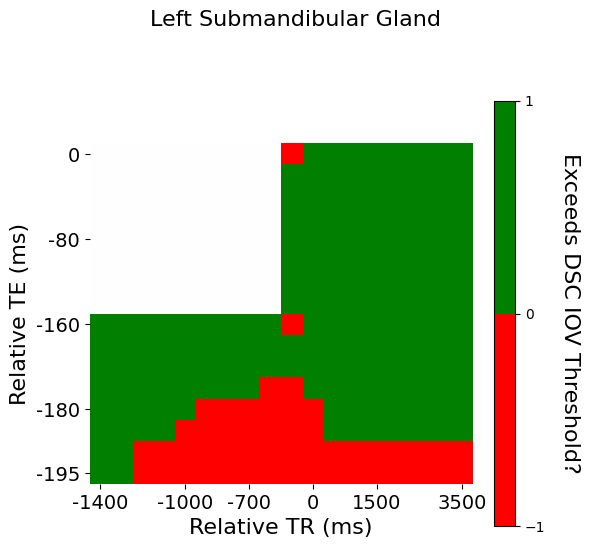

Dice Score Parotid_R All 134
Dice Score Parotid_R T2w 72


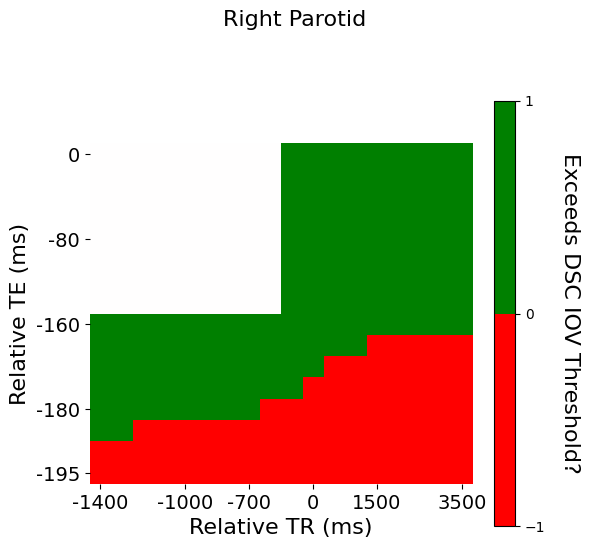

Dice Score Glnd_Submand_R All 121
Dice Score Glnd_Submand_R T2w 64


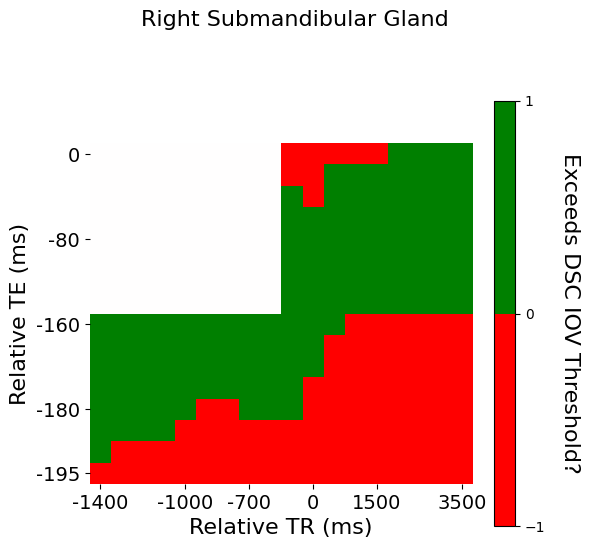

Dice Score Parotid_L All 208
Dice Score Parotid_L T2w 72


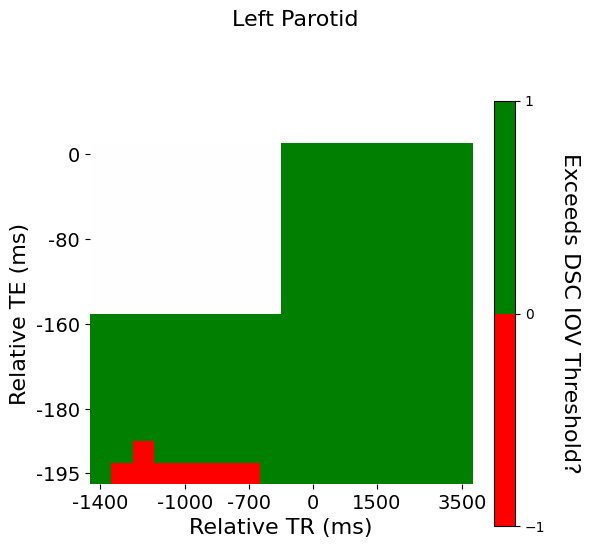

Hausdorff Distance (95th Percentile) Glnd_Submand_L All 167
Hausdorff Distance (95th Percentile) Glnd_Submand_L T2w 72


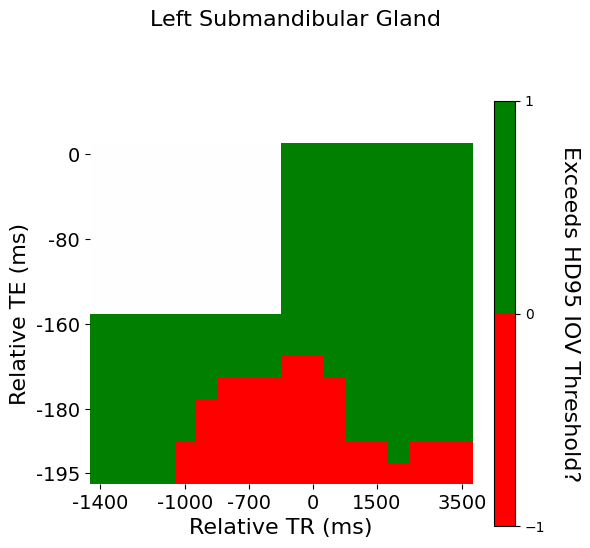

Hausdorff Distance (95th Percentile) Parotid_R All 191
Hausdorff Distance (95th Percentile) Parotid_R T2w 72


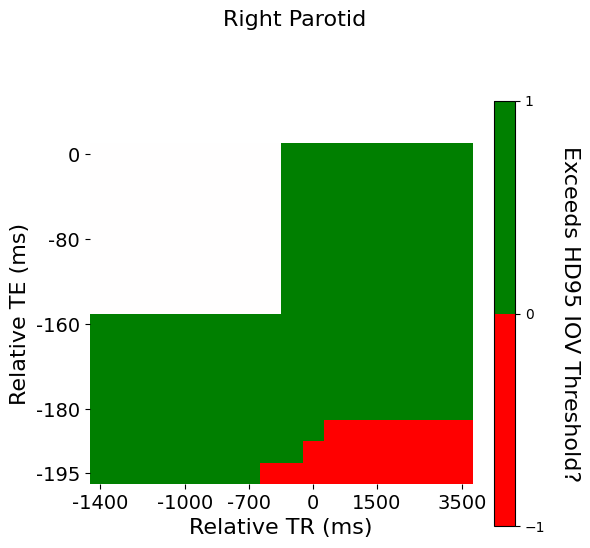

Hausdorff Distance (95th Percentile) Glnd_Submand_R All 142
Hausdorff Distance (95th Percentile) Glnd_Submand_R T2w 60


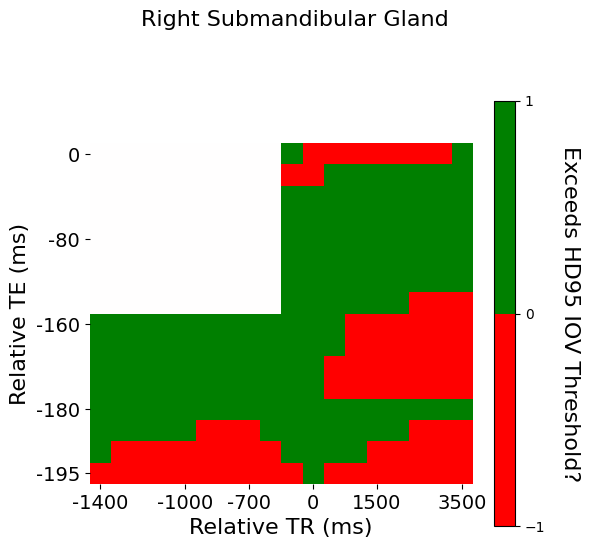

Hausdorff Distance (95th Percentile) Parotid_L All 194
Hausdorff Distance (95th Percentile) Parotid_L T2w 72


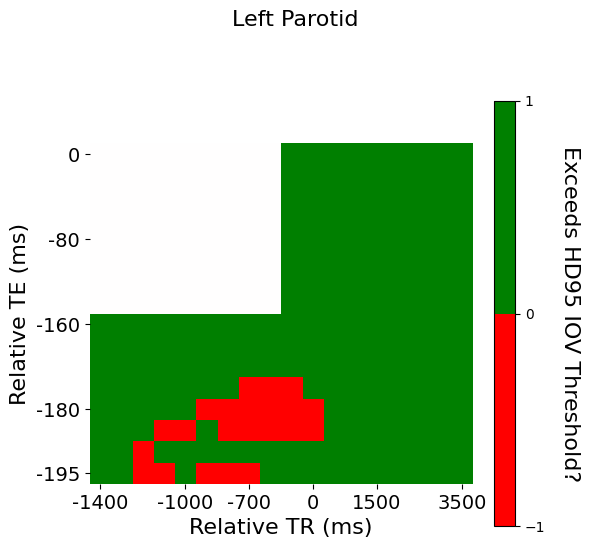

difference


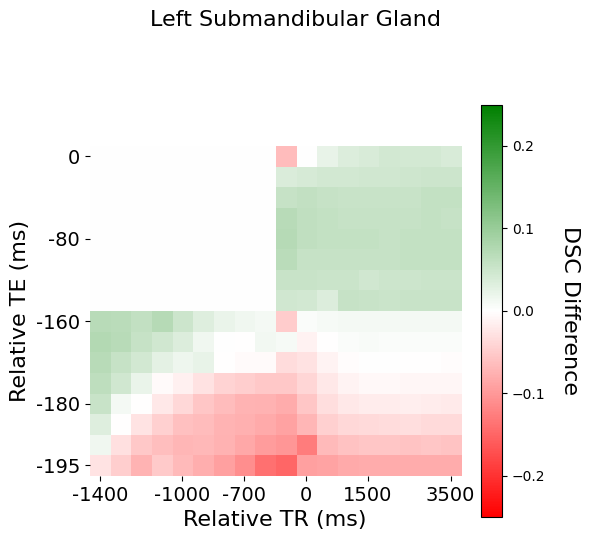

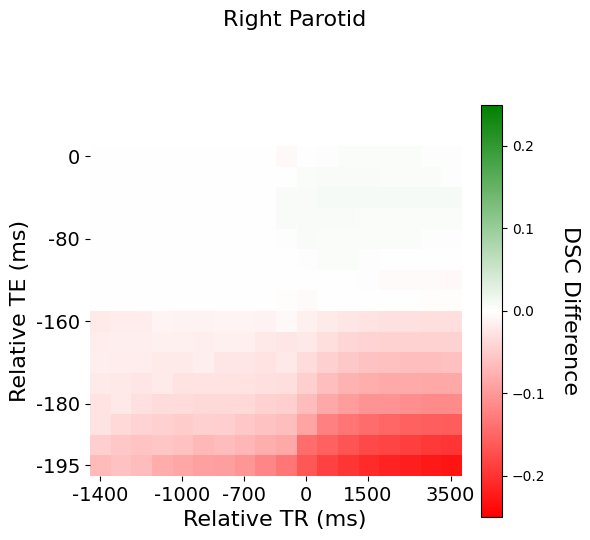

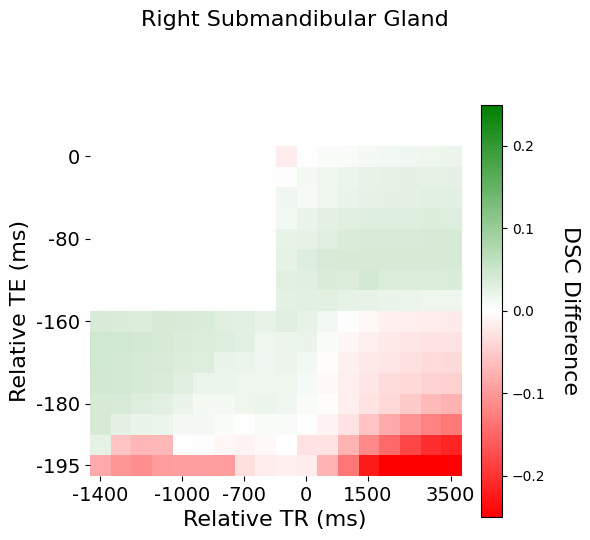

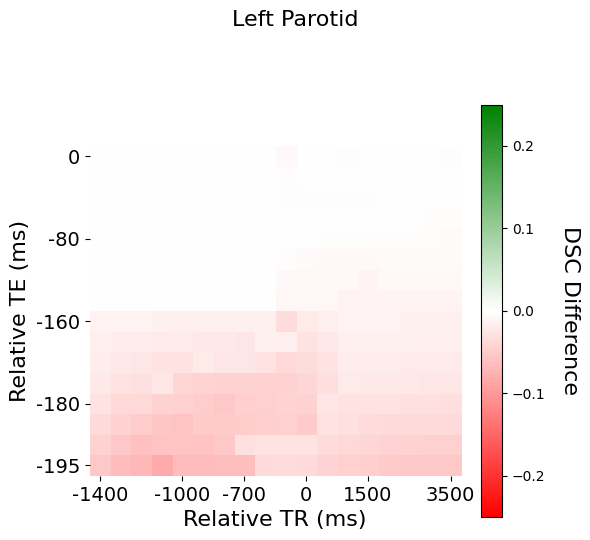

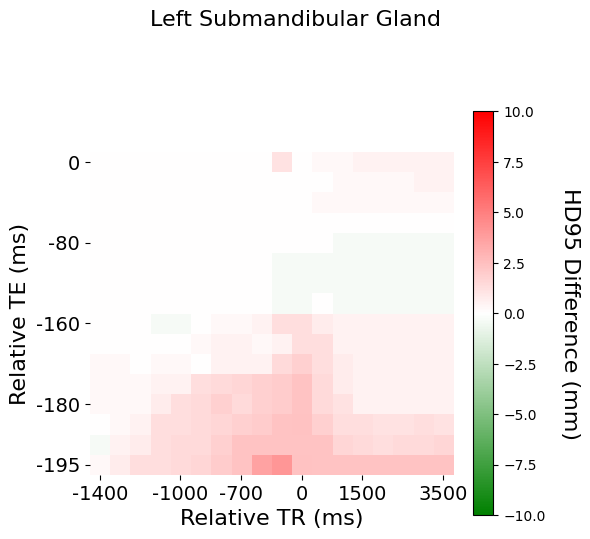

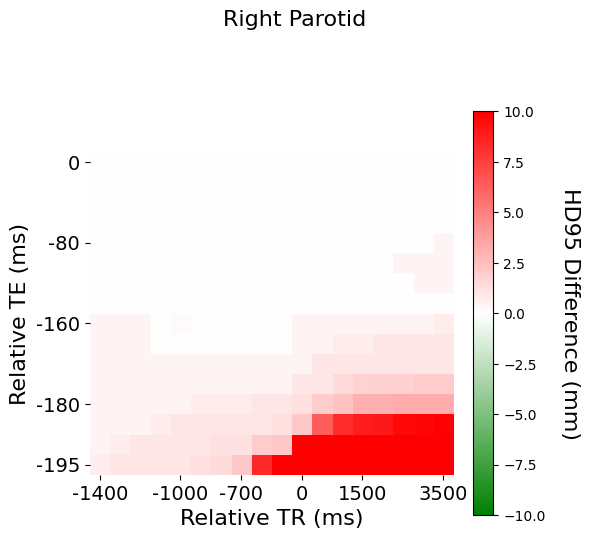

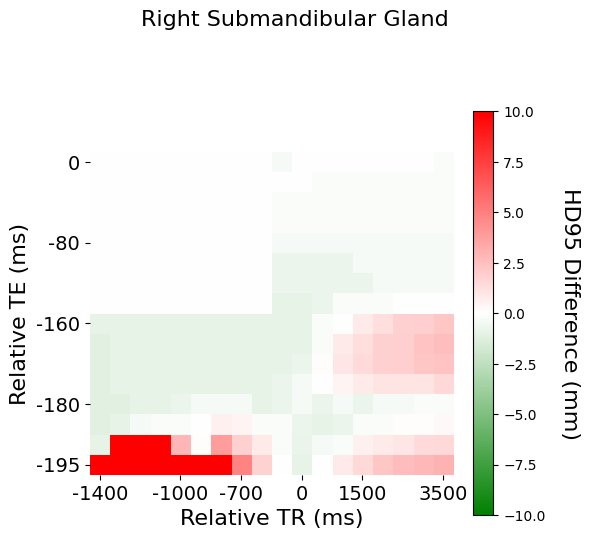

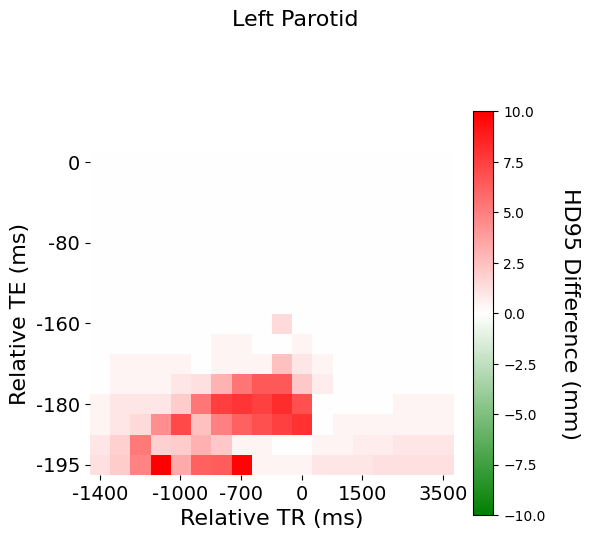

relative difference


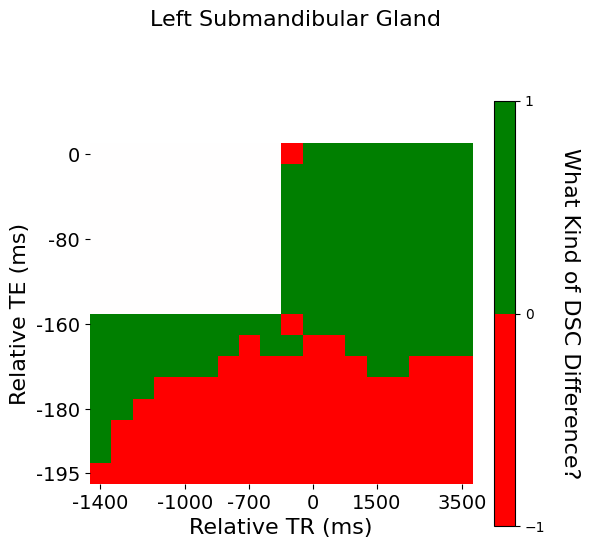

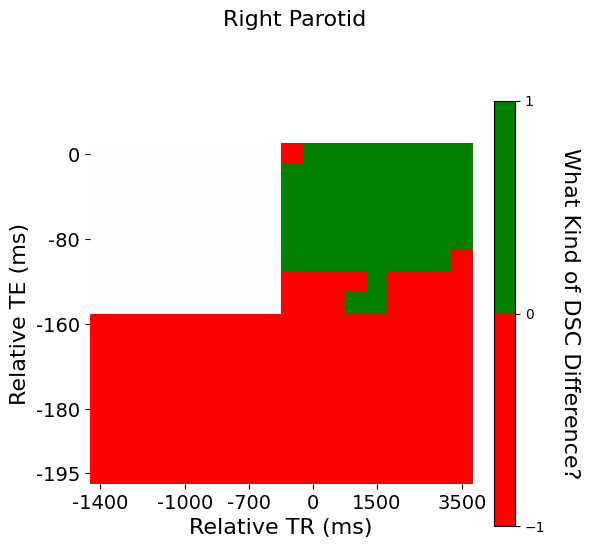

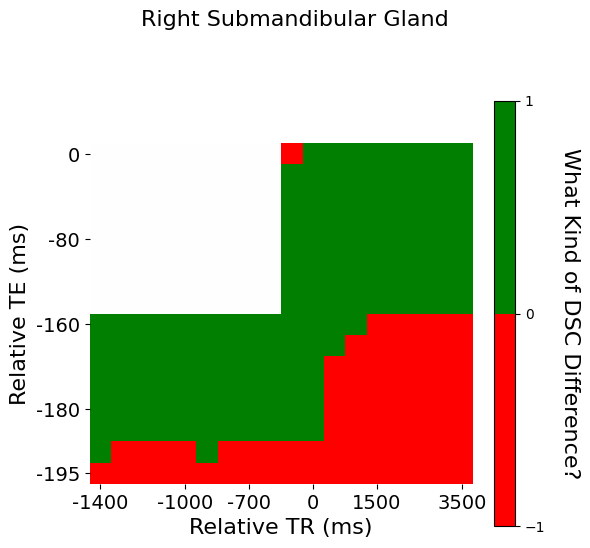

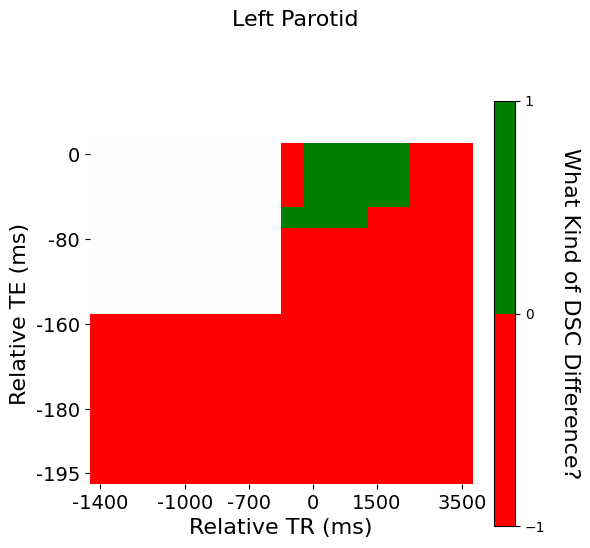

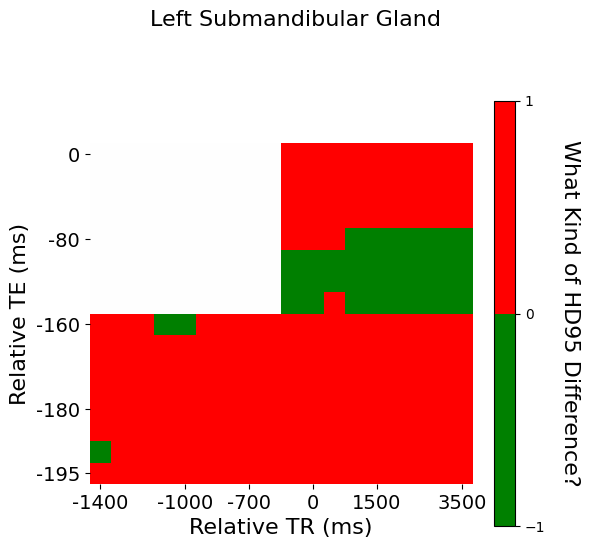

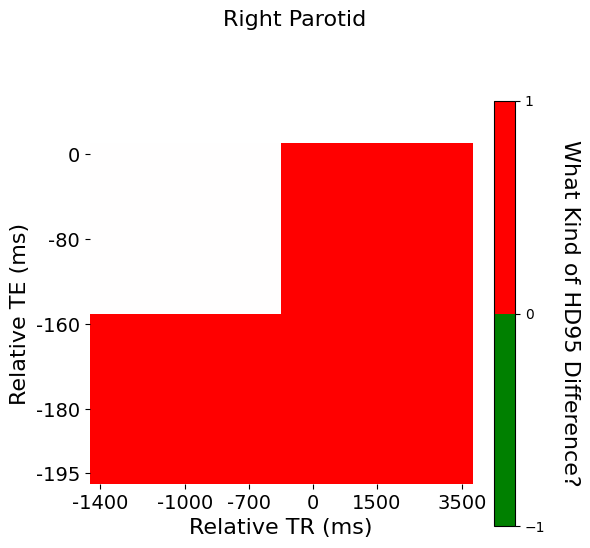

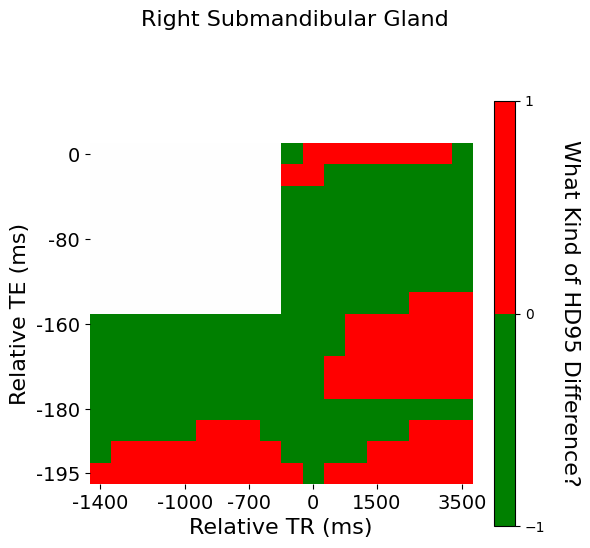

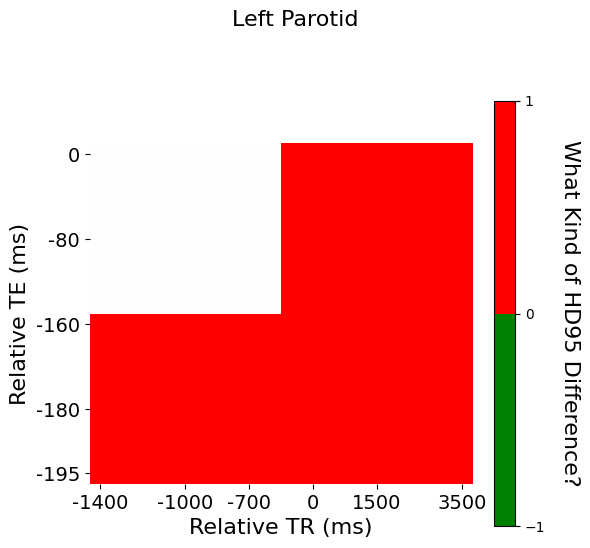

In [10]:
# Find the closest TR/TE combination to the reference
closest_TR_TE_combo = sorted([(math.sqrt(sum([(k[0]-TR_REF)**2, (k[1]-TE_REF)**2])), (k[0],k[1])) for k in all_DL_segs.keys()], key=lambda k:k[0])[0][1]
IOV_dict = {
    # DOI: 10.1002/mp.16582
    'Dice Score': {
        'Parotid_L': 0.83,
        'Parotid_R': 0.84,
        'Glnd_Submand_L': 0.75,
        'Glnd_Submand_R': 0.78
    },
    # DOI: 10.1186/s13014-020-01677-2
    'Hausdorff Distance (95th Percentile)': {
        'Parotid_L': 4.9,
        'Parotid_R': 5.1,
        'Glnd_Submand_L': 3.1,
        'Glnd_Submand_R': 3.1
    }
}
comparison_types = ['IOV', 'difference', 'relative difference']

r2g_cmap = LinearSegmentedColormap.from_list('rg', ['r','w','g'], N=256)
g2r_cmap = LinearSegmentedColormap.from_list('gr', ['g','w','r'], N=256)
all_metrics = ['Dice Score', 'Hausdorff Distance (95th Percentile)']

for comparison_type in comparison_types:
    print(comparison_type)

    for metric in all_metrics:
        if metric == 'Dice Score':
            saved_metric = 'DSC'
        elif metric == 'Hausdorff Distance (95th Percentile)':
            saved_metric = 'HD95'

        for seg_name in ALL_SEG_NAMES:
            fig,ax = plt.subplots(1, 1, figsize=(6,6))
            plot_matrix = np.zeros((len(all_TE), len(all_TR)))
            plot_matrix[:] = np.nan

            for temp_weighting in all_DL_segs.keys():
                temp_TR = temp_weighting[0]
                temp_TE = temp_weighting[1]
                temp_TR_ind = all_TR.index(temp_TR)
                temp_TE_ind = all_TE.index(temp_TE)
                try:
                    if comparison_type == 'difference':
                        plot_matrix[temp_TE_ind, temp_TR_ind] = all_DL_segs[temp_weighting][seg_name][metric] - all_DL_segs[closest_TR_TE_combo][seg_name][metric]
                    elif comparison_type == 'relative difference':
                        if all_DL_segs[closest_TR_TE_combo][seg_name][metric] > all_DL_segs[temp_weighting][seg_name][metric]:
                            plot_matrix[temp_TE_ind, temp_TR_ind] = -1
                        elif all_DL_segs[closest_TR_TE_combo][seg_name][metric] == all_DL_segs[temp_weighting][seg_name][metric]:
                            plot_matrix[temp_TE_ind, temp_TR_ind] = 0.5
                        else:
                            plot_matrix[temp_TE_ind, temp_TR_ind] = 1
                    elif comparison_type == 'IOV':
                        if all_DL_segs[temp_weighting][seg_name][metric] >= IOV_dict[metric][seg_name]:
                            if saved_metric == 'HD95':
                                plot_matrix[temp_TE_ind, temp_TR_ind] = -1
                            else:
                                plot_matrix[temp_TE_ind, temp_TR_ind] = 1
                        else:
                            if saved_metric == 'HD95':
                                plot_matrix[temp_TE_ind, temp_TR_ind] = 1
                            else:
                                plot_matrix[temp_TE_ind, temp_TR_ind] = -1
                except TypeError:
                    plot_matrix[temp_TE_ind, temp_TR_ind] = np.nan

            if (comparison_type == 'IOV'):
                print(metric, seg_name, 'All', np.where(plot_matrix==1)[0].size)
                print(metric, seg_name, 'T2w', np.where(plot_matrix[8:,9:]==1)[0].size)

            if saved_metric == 'DSC':
                # Fill in the mixed contrast region with white
                plot_matrix[-all_TE.index(60):,:all_TR.index(1000)] = 0
                plot_im = ax.imshow(plot_matrix, cmap=r2g_cmap, vmin=-0.25, vmax=0.25, origin='lower')
            elif saved_metric == 'HD95':
                # Fill in the mixed contrast region with white
                plot_matrix[-all_TE.index(60):,:all_TR.index(1000)] = 0
                if comparison_type == 'difference':
                    plot_im = ax.imshow(plot_matrix, cmap=g2r_cmap, vmin=-10, vmax=10, origin='lower') # 0, 100
                elif comparison_type == 'relative difference':
                    plot_im = ax.imshow(plot_matrix, cmap=g2r_cmap, vmin=-0.25, vmax=0.25, origin='lower')
                elif comparison_type == 'IOV':
                    plot_im = ax.imshow(plot_matrix, cmap=r2g_cmap, vmin=-0.25, vmax=0.25, origin='lower')

            TR_keep_inds = [100, 500, 800, 1500, 3000, 5000]
            TE_keep_inds = [5, 20, 40, 120, 200]
            ax.set_xticks([all_TR.index(ind) for ind in TR_keep_inds])
            ax.set_yticks([all_TE.index(ind) for ind in TE_keep_inds])
            TR_keep_inds = [idx-closest_TR_TE_combo[0] for idx in [100, 500, 800, 1500, 3000, 5000]]
            TE_keep_inds = [idx-closest_TR_TE_combo[1] for idx in [5, 20, 40, 120, 200]]
            ax.set_xticklabels(TR_keep_inds, fontsize=14)
            ax.set_yticklabels(TE_keep_inds, fontsize=14)
            ax.set_xlabel('Relative TR (ms)', fontsize=16)
            ax.set_ylabel('Relative TE (ms)', fontsize=16)
            if 'Glnd_Submand' in seg_name:
                temp_title = seg_name.replace('Glnd_Submand','Submandibular Gland')
            else:
                temp_title = seg_name
            if '_L' in seg_name:
                temp_title = temp_title.replace('_L','')
                temp_title = f'Left {temp_title}'
            elif '_R' in seg_name:
                temp_title = temp_title.replace('_R','')
                temp_title = f'Right {temp_title}'
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
            # Replace nan values with black
            ax.set_facecolor('k')

            plt.suptitle(temp_title, fontsize=16)
            if comparison_type == 'difference':
                colorbar = plt.colorbar(plot_im, ax=ax, fraction=0.05)
            elif comparison_type in ['IOV','relative difference']:
                colorbar = plt.colorbar(plot_im, ax=ax, fraction=0.05, boundaries=[-1,0,1], ticks=[-1,0,1])
            if comparison_type == 'IOV':
                plot_title = f'Exceeds {saved_metric} IOV Threshold?'
            elif comparison_type == 'difference':
                plot_title = f'{saved_metric} Difference'
                if saved_metric == 'HD95':
                    plot_title += ' (mm)'
            elif comparison_type == 'relative difference':
                plot_title = f'What Kind of {saved_metric} Difference?'
            colorbar.ax.set_ylabel(plot_title, fontsize=16, rotation=270, labelpad=25)
            plt.tight_layout()
            # plt.savefig(os.path.join('figures',f'TR-vs-TE___{saved_metric}___{seg_name}___{SUBJECT_ID}'))
            plt.show()

# Get the statistical performance in each quadrant

In [11]:
n_DL_models = 5
all_weightings = []
all_performances = {
    seg_name : {
        weighting: {
            'Dice Score': [],
            'Hausdorff Distance (95th Percentile)': []
        }
        for weighting in ['T1','T2','PD']
    }
    for seg_name in ALL_SEG_NAMES
}
performance_metrics = ['Dice Score', 'Hausdorff Distance (95th Percentile)']

for current_struct in all_performances.keys():
    for temp_TR,temp_TE in all_DL_segs.keys():
        if (temp_TR <= 900) and (temp_TE <= 40):
            weighting_bin = 'T1'
        elif (temp_TR >= 1000) and (temp_TE >= 60):
            weighting_bin = 'T2'
        elif (temp_TR >= 1000) and (temp_TE <= 40):
            weighting_bin = 'PD'
        all_weightings.append(weighting_bin)

        for performance_metric in performance_metrics:
            try:
                all_performances[current_struct][weighting_bin][performance_metric].append(
                    all_DL_segs[(temp_TR,temp_TE)][current_struct][performance_metric]
                )
            except TypeError:
                all_performances[current_struct][weighting_bin][performance_metric].append(np.nan)

print(Counter(all_weightings))

Counter({'PD': 288, 'T2': 288, 'T1': 288})


In [12]:
for performance_metric in performance_metrics:
    print(f'\t{performance_metric}')
    for current_struct in all_performances.keys():
        print(f'\t\t{current_struct}')
        print(
            '\t\t\tT1: ' + str(round(np.nanmedian(all_performances[current_struct]['T1'][performance_metric]),2)) + '(' + str(round(np.nanstd(all_performances[current_struct]['T1'][performance_metric]),2)) + ') [' + str(round(np.nanmin(all_performances[current_struct]['T1'][performance_metric]),2)) + ', ' + str(round(np.nanmax(all_performances[current_struct]['T1'][performance_metric]),2)) + ']'
        )
        print(
            '\t\t\tT2: ' + str(round(np.nanmedian(all_performances[current_struct]['T2'][performance_metric]),2)) + '(' + str(round(np.nanstd(all_performances[current_struct]['T2'][performance_metric]),2)) + ') [' + str(round(np.nanmin(all_performances[current_struct]['T2'][performance_metric]),2)) + ', ' + str(round(np.nanmax(all_performances[current_struct]['T2'][performance_metric]),2)) + ']'
        )
        print(
            '\t\t\tPD: ' + str(round(np.nanmedian(all_performances[current_struct]['PD'][performance_metric]),2)) + '(' + str(round(np.nanstd(all_performances[current_struct]['PD'][performance_metric]),2)) + ') [' + str(round(np.nanmin(all_performances[current_struct]['PD'][performance_metric]),2)) + ', ' + str(round(np.nanmax(all_performances[current_struct]['PD'][performance_metric]),2)) + ']'
        )
        print()
    print()


	Dice Score
		Glnd_Submand_L
			T1: 0.79(0.05) [0.66, 0.87]
			T2: 0.85(0.02) [0.73, 0.87]
			PD: 0.78(0.04) [0.65, 0.81]

		Parotid_R
			T1: 0.85(0.02) [0.76, 0.87]
			T2: 0.89(0.0) [0.87, 0.89]
			PD: 0.8(0.06) [0.65, 0.87]

		Glnd_Submand_R
			T1: 0.79(0.04) [0.66, 0.81]
			T2: 0.79(0.01) [0.75, 0.81]
			PD: 0.74(0.08) [0.43, 0.8]

		Parotid_L
			T1: 0.85(0.02) [0.81, 0.88]
			T2: 0.89(0.0) [0.88, 0.89]
			PD: 0.86(0.01) [0.83, 0.88]


	Hausdorff Distance (95th Percentile)
		Glnd_Submand_L
			T1: 2.24(0.8) [1.41, 5.39]
			T2: 1.73(0.31) [1.41, 2.83]
			PD: 3.0(0.77) [2.24, 5.82]

		Parotid_R
			T1: 1.41(1.02) [1.0, 9.43]
			T2: 1.0(0.11) [1.0, 1.41]
			PD: 2.83(9.36) [1.0, 31.39]

		Glnd_Submand_R
			T1: 2.24(7.3) [2.0, 24.68]
			T2: 3.0(0.24) [2.24, 3.16]
			PD: 3.32(1.12) [2.24, 6.16]

		Parotid_L
			T1: 1.71(2.8) [1.0, 13.0]
			T2: 1.0(0.0) [1.0, 1.0]
			PD: 1.41(1.87) [1.0, 9.27]


